In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
pd.set_option("display.max_rows", None)

In [ ]:
class EMAlgorithm:
    def __init__(self, X, no_of_clusters, no_of_points, features, max_iters=100, tolerance=1e-12):
        self.X = X
        self.no_of_clusters = no_of_clusters
        self.no_of_points = no_of_points
        self.features = features
        self.max_iters = max_iters
        self.tolerance = tolerance
        self.prevs = None
        self.Pis = None
        self.Probs = None
        self.gamma = None

    def E_step(self):
        for i in range(len(self.X)):
            original_values = self.Pis * np.prod((((2 * self.Probs.T) ** (self.X[i][np.newaxis, :]))).T, axis=0) * np.prod((((2 * (1 - self.Probs.T)) ** (1 - self.X[i][np.newaxis, :]))).T, axis=0)
            max_value = np.max(original_values)
            scaled_values = original_values / max_value

            sum_scaled_values = np.sum(scaled_values)
            normalized_values = scaled_values / sum_scaled_values
            self.gamma[i] = normalized_values

    def M_step(self):
        self.Pis = np.sum(self.gamma, axis=0) / len(self.X)

        Probsn = np.random.rand(self.no_of_clusters, self.features)
        for k in range(self.no_of_clusters):
            num = 0
            deno = 0
            for i in range(len(self.X)):
                num += self.gamma[i][k] * self.X[i]
                deno += self.gamma[i][k]
            Probsn[k] = num / deno
        self.Probs = Probsn.T.copy()
        del Probsn

    def clusterize(self):
        temp = [np.zeros(self.features) for _ in range(self.no_of_clusters)]
        count = [0] * self.no_of_clusters

        for i in range(len(self.X)):
            cluster_index = np.argmax(self.gamma[i])
            temp[cluster_index] += self.X[i]
            count[cluster_index] += 1

        return temp, count

    def run(self):
        self.Pis = np.ones(self.no_of_clusters) / self.no_of_clusters
        self.Probs = np.random.rand(self.features, self.no_of_clusters)
        self.gamma = np.zeros((len(self.X), self.no_of_clusters))

        for to in range(self.max_iters):
            print(f"Iteration {to + 1}")
            Pis_old = self.Pis.copy()
            Probs_old = self.Probs.copy()

            self.E_step()
            self.M_step()

            if np.max(np.abs(self.Pis - Pis_old)) < self.tolerance and np.max(np.abs(self.Probs - Probs_old)) < self.tolerance:
                print("Converged.")
                break

        return self.Pis, self.Probs, self.gamma

    def plot_results(self, indices, mus):
        num_plots = len(indices)
        fig, axes = plt.subplots(1, num_plots, figsize=(15, 5))

        for ax, (j, i) in zip(axes, indices):
            result_image = mus[0][i] / mus[1][i]
            result_image = result_image.reshape(28, 28)

            ax.imshow(result_image, cmap='binary')
            ax.axis('off')

        plt.tight_layout()
        plt.show()



In [ ]:
mnist = fetch_openml("mnist_784")

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [ ]:
X = mnist.data
y = mnist.target

In [ ]:
X = X.to_numpy()
X[X<128]=0
X[X>=128]=1
X = pd.DataFrame(X)

In [ ]:
X["y"] = y

In [ ]:
X = X[(y=='2') | (y=='3') | (y=='4')]

In [ ]:
X=X.drop("y",axis=1)

In [ ]:
X = X.to_numpy()

In [ ]:
em_algo = EMAlgorithm(X, 3, len(X), 784, max_iters=20)

In [ ]:
Pis, Probs, gamma = em_algo.run()

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20


In [ ]:
Probs.shape

(784, 3)

In [ ]:
gamma

array([[1.00000000e+00, 6.03152998e-63, 1.81013436e-38],
       [5.08930318e-30, 3.75595151e-35, 1.00000000e+00],
       [9.40109218e-50, 1.00000000e+00, 6.89253447e-22],
       ...,
       [9.19130551e-73, 1.60274952e-24, 1.00000000e+00],
       [1.51643336e-73, 1.00000000e+00, 1.32868419e-34],
       [1.00000000e+00, 5.27674345e-30, 2.47322386e-42]])

In [ ]:
mus = em_algo.clusterize()

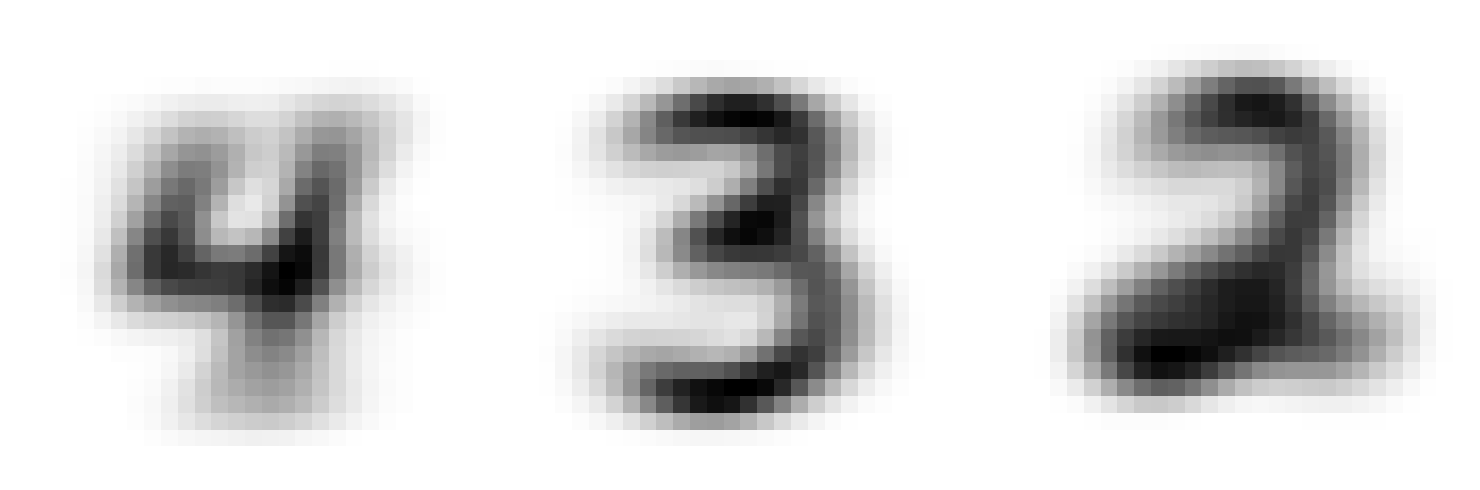

In [ ]:
indices = [(0, 0), (0, 1), (0, 2)]

em_algo.plot_results(indices, mus)